Loading dataset: Rutile-DS-2.xlsx
Loaded dataset shape: (3471, 11)
Dataset columns: ['Zr', 'Hf', 'Th', 'U', 'Calibrated T(℃)']
Dataset shape: (3471, 5)

Temperature Category Distribution:
  Low-T (<600°C): 813 samples (23.4%)
  Mid-T (600-800°C): 2359 samples (68.0%)
  High-T (800-1000°C): 255 samples (7.3%)
  Very High-T (>1000°C): 44 samples (1.3%)

Training Set Distribution:
  Low-T (<600°C): 650 samples (23.4%)
  Mid-T (600-800°C): 1887 samples (68.0%)
  High-T (800-1000°C): 204 samples (7.3%)
  Very High-T (>1000°C): 35 samples (1.3%)

Test Set Distribution:
  Low-T (<600°C): 163 samples (23.5%)
  Mid-T (600-800°C): 472 samples (67.9%)
  High-T (800-1000°C): 51 samples (7.3%)
  Very High-T (>1000°C): 9 samples (1.3%)

High-T Samples (>1000°C) in Train: 35 (1.3%)
High-T Samples (>1000°C) in Test: 9 (1.3%)

✓ SCALER SAVED: Scaler_Rutile_DS2.pkl
  Min values: [0.084  0.011  0.0005 0.0025]
  Max values: [70845.8  2967.  13600.   7240. ]
  Features: ['Zr', 'Hf', 'Th', 'U']


--- Traini

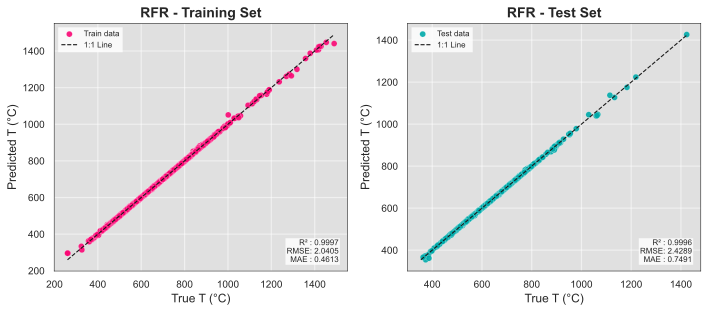


RFR (Train) - Residual Statistics:
Mean residual: -0.0047
Std residual:  2.0405
Min residual:  -49.7547
Max residual:  49.1107


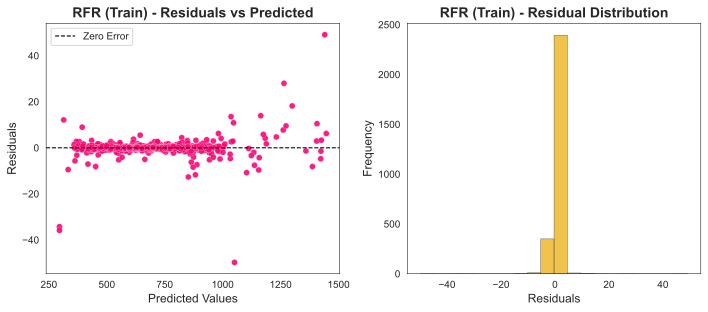


RFR (Test) - Residual Statistics:
Mean residual: 0.1892
Std residual:  2.4215
Min residual:  -22.9571
Max residual:  25.2591


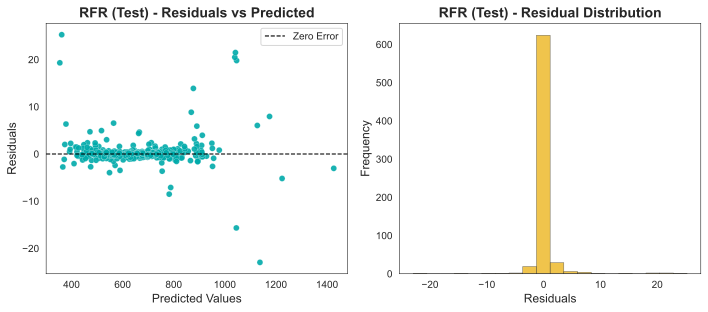


TRAINING COMPLETE!


In [1]:
import pandas as pd
import numpy as np
from joblib import dump
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties
from matplotlib_inline.backend_inline import set_matplotlib_formats
import warnings

set_matplotlib_formats('svg')
warnings.filterwarnings('ignore')

FONT_FAMILY = 'Arial'
plt.rc('font', family=FONT_FAMILY)

title_font = FontProperties(family=FONT_FAMILY, size=14, weight='bold')
label_font = FontProperties(family=FONT_FAMILY, size=12)
tick_font = FontProperties(family=FONT_FAMILY, size=10)
value_font = FontProperties(family=FONT_FAMILY, size=10)
legend_font = FontProperties(family=FONT_FAMILY, size=10)

plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#CCCCCC'
plt.rcParams['grid.alpha'] = 0.5

sns.set(style='whitegrid', palette='muted', font_scale=1.0)

TRUE_PRED_SCATTER_FIGSIZE = (10, 4.5)
RESIDUAL_ANALYSIS_FIGSIZE = (10, 4.5)
SCATTER_TRAIN_COLOR = "#fa0775"
SCATTER_TEST_COLOR = "#00AAAA"
SCATTER_SIZE = 36
SCATTER_ALPHA = 0.9
SCATTER_EDGE_WIDTH = 0.2

RANDOM_STATE = 18
TEST_SIZE = 0.2
DATASET_PATH = 'Rutile-DS-2.xlsx'
DATASET_NAME = 'Rutile_DS2'

BEST_PARAMS = {}

def preprocess_data(df, test_size=TEST_SIZE, random_state=RANDOM_STATE):
    selected_cols = ['Zr', 'Hf', 'Th', 'U', 'Calibrated T(℃)']
    df = df[selected_cols].copy()
    
    print("Dataset columns:", df.columns.tolist())
    print("Dataset shape:", df.shape)

    x = df[['Zr', 'Hf', 'Th', 'U']]
    y = df['Calibrated T(℃)']

    bins = [y.min(), 600, 800, 1000, y.max()]
    bin_labels = ['Low-T (<600°C)', 'Mid-T (600-800°C)', 'High-T (800-1000°C)', 'Very High-T (>1000°C)']
    y_categories = pd.cut(y, bins=bins, labels=bin_labels, include_lowest=True)
    
    print("\nTemperature Category Distribution:")
    category_counts = y_categories.value_counts().sort_index()
    for category, count in category_counts.items():
        percentage = (count / len(y)) * 100
        print(f"  {category}: {count} samples ({percentage:.1f}%)")
    
    xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=test_size, random_state=random_state, stratify=y_categories)
    
    print("\nTraining Set Distribution:")
    train_categories = pd.cut(ytrain, bins=bins, labels=bin_labels, include_lowest=True)
    for category in bin_labels:
        train_count = (train_categories == category).sum()
        train_percent = (train_count / len(ytrain)) * 100
        print(f"  {category}: {train_count} samples ({train_percent:.1f}%)")
    
    print("\nTest Set Distribution:")
    test_categories = pd.cut(ytest, bins=bins, labels=bin_labels, include_lowest=True)
    for category in bin_labels:
        test_count = (test_categories == category).sum()
        test_percent = (test_count / len(ytest)) * 100
        print(f"  {category}: {test_count} samples ({test_percent:.1f}%)")
    
    high_T_train = (ytrain > 1000).sum()
    high_T_test = (ytest > 1000).sum()
    print(f"\nHigh-T Samples (>1000°C) in Train: {high_T_train} ({high_T_train/len(ytrain)*100:.1f}%)")
    print(f"High-T Samples (>1000°C) in Test: {high_T_test} ({high_T_test/len(ytest)*100:.1f}%)")

    scaler = MinMaxScaler()
    xtrain_scaled = scaler.fit_transform(xtrain)
    xtest_scaled = scaler.transform(xtest)

    return (xtrain_scaled, xtest_scaled, ytrain, ytest, xtrain.columns.tolist(),
            xtrain.values, xtest.values, scaler)

def calculate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"R2 Score: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    return r2, rmse, mae

def save_best_model(model, model_name, dataset_name):
    model_path = f"{model_name}_{dataset_name}.pkl"
    dump(model, model_path)
    print("Best model saved to:", model_path)
    return model_path

def add_plot_borders(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_edgecolor('black')

def plot_residual_scatter_train(ax, x_data, y_data):
    ax.scatter(x_data, y_data, s=SCATTER_SIZE, color=SCATTER_TRAIN_COLOR,
               alpha=SCATTER_ALPHA, edgecolor="#FFFFFF", linewidth=SCATTER_EDGE_WIDTH)
    return ax

def plot_residual_scatter_test(ax, x_data, y_data):
    ax.scatter(x_data, y_data, s=SCATTER_SIZE, color=SCATTER_TEST_COLOR,
               alpha=SCATTER_ALPHA, edgecolor="#FFFFFF", linewidth=SCATTER_EDGE_WIDTH)
    return ax

def plot_residual_analysis(y_true, y_pred, model_name):
    residuals = y_true.values - y_pred
    fig, axes = plt.subplots(1, 2, figsize=RESIDUAL_ANALYSIS_FIGSIZE)

    if "Train" in model_name:
        plot_residual_scatter_train(axes[0], y_pred, residuals)
    else:
        plot_residual_scatter_test(axes[0], y_pred, residuals)

    axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1.1, label='Zero Error', zorder=7)
    axes[0].set_xlabel("Predicted Values", fontproperties=label_font)
    axes[0].set_ylabel("Residuals", fontproperties=label_font)
    axes[0].set_title(f"{model_name} - Residuals vs Predicted", fontproperties=title_font)
    axes[0].tick_params(labelsize=10)
    axes[0].legend(prop=legend_font)
    axes[0].grid(False)
    axes[0].tick_params(axis='both', which='major', direction='out', length=3.5, width=0.8, color='black')
    axes[0].locator_params(axis='x', nbins=6)
    axes[0].locator_params(axis='y', nbins=6)
    add_plot_borders(axes[0])

    axes[1].hist(residuals, bins=20, color="#E9AB00", alpha=0.7, edgecolor='black', linewidth=0.4)
    axes[1].set_xlabel("Residuals", fontproperties=label_font)
    axes[1].set_ylabel("Frequency", fontproperties=label_font)
    axes[1].set_title(f"{model_name} - Residual Distribution", fontproperties=title_font)
    axes[1].tick_params(labelsize=10)
    axes[1].grid(False)
    axes[1].tick_params(axis='both', which='major', direction='out', length=3.5, width=0.8, color='black')
    axes[1].locator_params(axis='x', nbins=6)
    add_plot_borders(axes[1])

    print(f"\n{model_name} - Residual Statistics:")
    print(f"Mean residual: {np.mean(residuals):.4f}")
    print(f"Std residual:  {np.std(residuals):.4f}")
    print(f"Min residual:  {np.min(residuals):.4f}")
    print(f"Max residual:  {np.max(residuals):.4f}")

    plt.tight_layout()
    plt.show()

def plot_true_vs_pred_scatter(y_train, y_train_pred, y_test, y_test_pred, train_metrics, test_metrics, model_name="Model"):
    fig, axes = plt.subplots(1, 2, figsize=TRUE_PRED_SCATTER_FIGSIZE)

    for ax in axes:
        ax.set_facecolor("#e0e0e0")
        ax.grid(color="white", linewidth=1.2)

    r2_tr, rmse_tr, mae_tr = train_metrics
    axes[0].scatter(y_train, y_train_pred, s=SCATTER_SIZE, color=SCATTER_TRAIN_COLOR,
                   alpha=SCATTER_ALPHA, edgecolor="#FFFFFF", linewidth=SCATTER_EDGE_WIDTH, label="Train data")
    min_val_tr = min(y_train.min(), y_train_pred.min())
    max_val_tr = max(y_train.max(), y_train_pred.max())
    axes[0].plot([min_val_tr, max_val_tr], [min_val_tr, max_val_tr], 'k--', linewidth=1.1, label="Fitted Line")
    axes[0].set_title(f"{model_name} - Training Set", fontproperties=title_font)
    axes[0].set_xlabel("True T (°C)", fontproperties=label_font)
    axes[0].set_ylabel("Predicted T (°C)", fontproperties=label_font)
    axes[0].tick_params(labelsize=10)

    leg0 = axes[0].legend(frameon=True, fancybox=False, loc='upper left', prop=FontProperties(family=FONT_FAMILY, size=8))
    leg0.get_frame().set_edgecolor('none')
    leg0.get_frame().set_linewidth(0.0)
    leg0.get_frame().set_facecolor('white')

    textstr_tr = "R² : {:.4f}\nRMSE: {:.4f}\nMAE : {:.4f}".format(r2_tr, rmse_tr, mae_tr)
    axes[0].text(0.97, 0.03, textstr_tr, transform=axes[0].transAxes, fontsize=8, va='bottom', ha='right',
                bbox=dict(boxstyle='square,pad=0.15', facecolor='white', edgecolor='none', alpha=0.8),
                fontproperties=value_font)
    add_plot_borders(axes[0])

    r2_te, rmse_te, mae_te = test_metrics
    axes[1].scatter(y_test, y_test_pred, s=SCATTER_SIZE, color=SCATTER_TEST_COLOR,
                   alpha=SCATTER_ALPHA, edgecolor="#FFFFFF", linewidth=SCATTER_EDGE_WIDTH, label="Test data")
    min_val_te = min(y_test.min(), y_test_pred.min())
    max_val_te = max(y_test.max(), y_test_pred.max())
    axes[1].plot([min_val_te, max_val_te], [min_val_te, max_val_te], 'k--', linewidth=1.1, label="Fitted Line")
    axes[1].set_title(f"{model_name} - Test Set", fontproperties=title_font)
    axes[1].set_xlabel("True T (°C)", fontproperties=label_font)
    axes[1].set_ylabel("Predicted T (°C)", fontproperties=label_font)
    axes[1].tick_params(labelsize=10)

    leg1 = axes[1].legend(frameon=True, fancybox=False, loc='upper left', prop=FontProperties(family=FONT_FAMILY, size=8))
    leg1.get_frame().set_edgecolor('none')
    leg1.get_frame().set_linewidth(0.0)
    leg1.get_frame().set_facecolor('white')

    textstr_te = "R² : {:.4f}\nRMSE: {:.4f}\nMAE : {:.4f}".format(r2_te, rmse_te, mae_te)
    axes[1].text(0.97, 0.03, textstr_te, transform=axes[1].transAxes, fontsize=8, va='bottom', ha='right',
                bbox=dict(boxstyle='square,pad=0.15', facecolor='white', edgecolor='none', alpha=0.8),
                fontproperties=value_font)
    add_plot_borders(axes[1])

    plt.tight_layout()
    plt.show()

def train_and_save_best_rfr_model(xtrain, ytrain, dataset_name):
    print("\n--- Training Random Forest Regressor ---")
    param_grid = {'n_estimators': [200], 'max_depth': [10], 'min_samples_split': [2],
                  'min_samples_leaf': [2], 'max_features': [0.8]}
    rfr = RandomForestRegressor(random_state=RANDOM_STATE)
    grid_search = GridSearchCV(estimator=rfr, param_grid=param_grid, cv=5, 
                               scoring='neg_mean_squared_error', n_jobs=1)
    grid_search.fit(xtrain, ytrain)
    rfr_best = grid_search.best_estimator_
    BEST_PARAMS["RFR"] = grid_search.best_params_
    save_best_model(rfr_best, 'RFR', dataset_name)
    print("\n" + "=" * 70)
    print("RFR HYPERPARAMETER TUNING RESULTS")
    print("=" * 70)
    print(f"\nBest parameters: {grid_search.best_params_}")
    return rfr_best

def main():
    try:
        print(f"Loading dataset: {DATASET_PATH}")
        df = pd.read_excel(DATASET_PATH)
        print(f"Loaded dataset shape: {df.shape}")
    except FileNotFoundError:
        print(f"ERROR: Dataset file not found at {DATASET_PATH}.")
        return

    preprocessed = preprocess_data(df, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    if preprocessed is None:
        return

    (x_train_scaled, x_test_scaled, y_train, y_test, feature_names,
     x_train_data_array, x_test_data_array, scaler) = preprocessed

    scaler_path = f'Scaler_{DATASET_NAME}.pkl'
    dump(scaler, scaler_path)
    print(f"\n{'='*70}")
    print(f"SCALER SAVED: {scaler_path}")
    print(f"  Min values: {scaler.data_min_}")
    print(f"  Max values: {scaler.data_max_}")
    print(f"  Features: {feature_names}")
    print(f"{'='*70}\n")

    rfr_best = train_and_save_best_rfr_model(x_train_scaled, y_train, DATASET_NAME)
    print("\n" + "--- RFR TRAINING SET EVALUATION ---".center(70, '-'))
    y_train_pred_rfr = rfr_best.predict(x_train_scaled)
    train_metrics_rfr = calculate_metrics(y_train, y_train_pred_rfr)
    print("\n" + "--- RFR TEST SET EVALUATION ---".center(70, '-'))
    y_test_pred_rfr = rfr_best.predict(x_test_scaled)
    test_metrics_rfr = calculate_metrics(y_test, y_test_pred_rfr)
    plot_true_vs_pred_scatter(y_train, y_train_pred_rfr, y_test, y_test_pred_rfr,
                              train_metrics_rfr, test_metrics_rfr, model_name="RFR")
    plot_residual_analysis(y_train, y_train_pred_rfr, "RFR (Train)")
    plot_residual_analysis(y_test, y_test_pred_rfr, "RFR (Test)")

    print("\n" + "="*70)
    print("All models trained and evaluated.")
    print("="*70)

if __name__ == "__main__":
    main()